# HDAC1 bioactivity: a fingerprint random forest vs. a message-passing GNN

**Does a message-passing graph neural network learn anything about HDAC1 inhibition that a
2048-bit ECFP4 random forest does not, when both are tested on chemical scaffolds neither has
seen?**

This notebook renders the result. It computes nothing: every number and figure is loaded from
the committed artifacts in `results/`, which are produced by `scripts/01`–`scripts/07`. That
separation is deliberate — re-running this notebook cannot change a result, only redisplay it.

To regenerate the artifacts themselves, see *Reproducing it* in the README.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA = ROOT / "data"
RESULTS = ROOT / "results"


def load(name: str) -> dict:
    return json.loads((RESULTS / name).read_text(encoding="utf-8"))


provenance = json.loads((DATA / "provenance.json").read_text(encoding="utf-8"))
manifest = load("split_manifest.json")
gates = load("gate_report.json")
rf_metrics = load("metrics_rf.json")
gnn_metrics = load("metrics_gnn.json")
comparison = load("comparison.json")
diagnostics = load("diagnostics.json") if (RESULTS / "diagnostics.json").exists() else None

print("split sha256:", manifest["split_assignment_sha256"])
print("both models on that split:",
      rf_metrics["split_sha256"] == gnn_metrics["split_sha256"] == manifest["split_assignment_sha256"])
print("both models scored by the same harness:",
      rf_metrics["evaluate_module_sha256"] == gnn_metrics["evaluate_module_sha256"])

split sha256: d25042a5a092210547bf09f218f3ec2c655ed5c545a1d3cdfecf3d00a4854537
both models on that split: True
both models scored by the same harness: True


## 1. The verdict

Generated from the paired bootstrap confidence interval in `comparison.json`, not written by
hand, so it cannot drift from the numbers below.

In [2]:
display(Markdown(f"> **{comparison['verdict']}**"))

delta = comparison["deltas"]["rmse"]
print(f"RF  RMSE {delta['point_a']:.4f}")
print(f"GNN RMSE {delta['point_b']:.4f}")
print(f"difference {delta['delta']:+.4f}  95% CI [{delta['lo']:+.4f}, {delta['hi']:+.4f}]  "
      f"p = {delta['p_value']:.3f}")

> **No significant difference in rmse between Random forest (ECFP4 + descriptors) and GINE graph neural network at this sample size: difference +0.0010 log units, 95% CI [-0.0307, +0.0293], p = 0.936.**

RF  RMSE 0.7367
GNN RMSE 0.7357
difference +0.0010  95% CI [-0.0307, +0.0293]  p = 0.936


## 2. The dataset

ChEMBL target `CHEMBL325` (histone deacetylase 1, *Homo sapiens*, UniProt Q13547). IC50 values
from binding assays with an exact relation, a defined pChEMBL value and a direct single-protein
target assignment, deduplicated to one median pIC50 per standardised parent compound.

In [3]:
funnel = provenance["funnel"]
cleaning = provenance.get("cleaning", {})
rows = [{"stage": k, "count": v} for k, v in funnel.items()]
for k, v in cleaning.get("funnel", {}).items():
    rows.append({"stage": k, "count": v})
display(pd.DataFrame(rows))

print("censored records excluded:", provenance["censored"]["n_censored"],
      f"({provenance['censored']['censored_fraction']:.1%} of measurements)")
print("max |recomputed pIC50 - ChEMBL pchembl_value|:",
      round(cleaning.get("max_abs_pic50_minus_pchembl", float('nan')), 6))
display(pd.DataFrame(cleaning.get("class_balance", {})).T)

,stage,count
0,fetched_exact_relation_pchembl,10048
1,organism_homo_sapiens,10048
2,standard_value_gt_0,10048
3,confidence_score_eq_9,8757
4,has_smiles,8757
5,unique_molecule_chembl_id,7057
6,raw_activity_rows,8757
7,standardized_ok_rows,8753
8,unique_inchikey,6913
9,n_rows_in,8753


censored records excluded: 1609 (15.5% of measurements)
max |recomputed pIC50 - ChEMBL pchembl_value|: 0.005496


,n_active,n_inactive,pos_rate
pIC50_ge_6.0,4690.0,2126.0,0.6881
pIC50_ge_6.5,3607.0,3209.0,0.5292
pIC50_ge_7.0,2488.0,4328.0,0.3650


## 3. The split, and why it is trustworthy

The split is computed once, written to `data/split_assignment.csv`, and hashed into
`results/split_manifest.json`. Both models load it through `src/split_contract.py`, which
re-verifies the digest; neither model is permitted to import the splitter. The figure below is
the leak-free argument made visually.

folds: {'train': 4771, 'val': 1023, 'test': 1022}  fractions: {'train': 0.7, 'val': 0.1501, 'test': 0.1499}
3128 Murcko scaffold groups, 7 acyclic compounds

gates: 26 run, 0 failed, 2 flagged
  FLAG L8_fingerprint_identical_to_train: 2 at sim=1.0 (ECFP4 bit collisions, distinct structures)
  FLAG L11_fingerprint_identical_to_train_val: 6 at sim=1.0 (ECFP4 bit collisions, distinct structures)


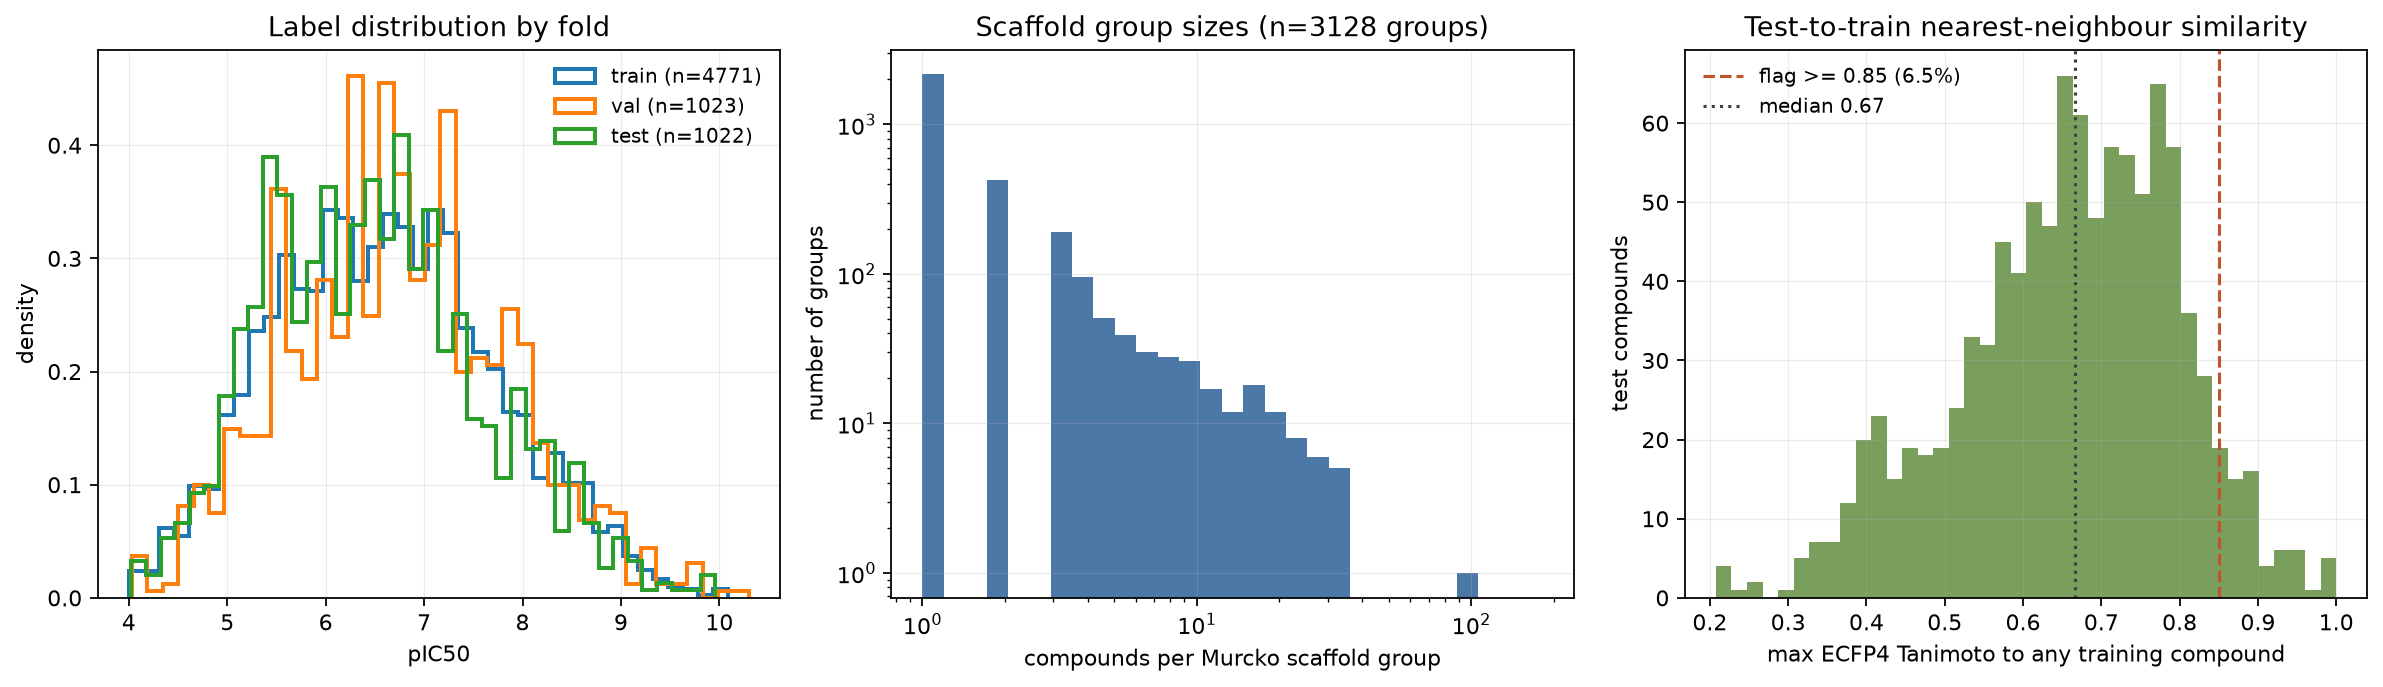

In [4]:
print(f"folds: {manifest['fold_sizes']}  fractions: "
      f"{ {k: round(v, 4) for k, v in manifest['fold_fractions'].items()} }")
print(f"{manifest['n_groups']} Murcko scaffold groups, {manifest['n_acyclic']} acyclic compounds")

failed = [g for g in gates["gates"] if not g["passed"] and g["severity"] == "fail"]
flagged = [g for g in gates["gates"] if not g["passed"] and g["severity"] == "flag"]
print(f"\ngates: {gates['n_gates']} run, {len(failed)} failed, {len(flagged)} flagged")
for g in flagged:
    print(f"  FLAG {g['name']}: {g['observed']}")
display(Image(filename=str(RESULTS / "fig_split_diagnostics.png")))

**On the absolute similarity level.** The median test-to-train Tanimoto is high in
absolute terms, because HDAC1's ChEMBL corpus is congeneric — nearly every compound is a
zinc-binding group, a linker and a cap. The relevant question is whether the scaffold split
separates chemotypes better than chance, which is why the gate is calibrated against a seeded
random-split control rather than an absolute constant.

In [5]:
sim = [g for g in gates["gates"] if "median" in g["name"] or "similarity" in g["name"]]
display(pd.DataFrame([{"gate": g["name"], "observed": g["observed"],
                       "expected": g["expected"], "severity": g["severity"],
                       "passed": g["passed"]} for g in sim]))

,gate,observed,expected,severity,passed
0,L9_high_similarity_reduction,test frac>=0.85: 0.0568 vs random 0.2581 (4.5x...,>= 2.0x fewer than random split,fail,True
1,L10_median_below_random,test median=0.6625 vs random 0.7857 (margin +0...,at least 0.05 below the random-split median,fail,True
2,L10b_median_absolute,test median=0.6625 (dataset is congeneric; ran...,"recorded, not gated",info,True
3,L11b_high_similarity_reduction_val,val frac>=0.85: 0.0547 vs random 0.2581 (4.7x ...,>= 2.0x fewer than random split,fail,True
4,L11c_median_below_random_val,val median=0.7021 vs random 0.7857 (margin +0....,at least 0.05 below the random-split median,fail,True
5,L11d_median_absolute_val,val median=0.7021 (dataset is congeneric; rand...,"recorded, not gated",info,True


## 4. The comparison

In [6]:
table = pd.DataFrame(comparison["table"])[
    ["model", "rmse", "mae", "r2", "spearman", "cls_roc_auc", "cls_pr_auc", "cls_mcc"]
].rename(columns={"cls_roc_auc": "ROC-AUC", "cls_pr_auc": "PR-AUC", "cls_mcc": "MCC"})
display(table.round(4))

print("\nPaired bootstrap, RF minus GNN (* = significant at 95%):")
for metric, d in comparison["deltas"].items():
    star = "*" if d["significant"] else " "
    print(f" {star} {metric:18s} {d['delta']:+.4f}  [{d['lo']:+.4f}, {d['hi']:+.4f}]  p={d['p_value']:.3f}")

,model,rmse,mae,r2,spearman,ROC-AUC,PR-AUC,MCC
0,mean predictor,1.1060,0.9007,-0.0166,NaN,0.5000,0.3092,0.0000
1,majority class,1.2015,0.9499,-0.1997,NaN,0.5000,0.3092,0.0000
2,random scores,2.2340,1.8290,-3.1473,0.0085,0.4831,0.2926,0.0109
3,1-NN Tanimoto,0.9440,0.6530,0.2594,0.6566,0.8180,0.6593,0.4660
4,Random forest (ECFP4 + descriptors),0.7367,0.5640,0.5490,0.7594,0.8779,0.7784,0.5636
5,GINE graph neural network,0.7357,0.5535,0.5502,0.7456,0.8670,0.7563,0.5250



Paired bootstrap, RF minus GNN (* = significant at 95%):
   rmse               +0.0010  [-0.0307, +0.0293]  p=0.936
   mae                +0.0105  [-0.0124, +0.0319]  p=0.370
   r2                 -0.0012  [-0.0350, +0.0390]  p=0.936
   spearman           +0.0138  [-0.0076, +0.0361]  p=0.229
   pearson            +0.0042  [-0.0182, +0.0286]  p=0.725
   roc_auc            +0.0109  [-0.0041, +0.0262]  p=0.147
   pr_auc             +0.0221  [-0.0112, +0.0587]  p=0.205
   mcc                +0.0386  [-0.0132, +0.0953]  p=0.145
   balanced_accuracy  -0.0059  [-0.0322, +0.0226]  p=0.664


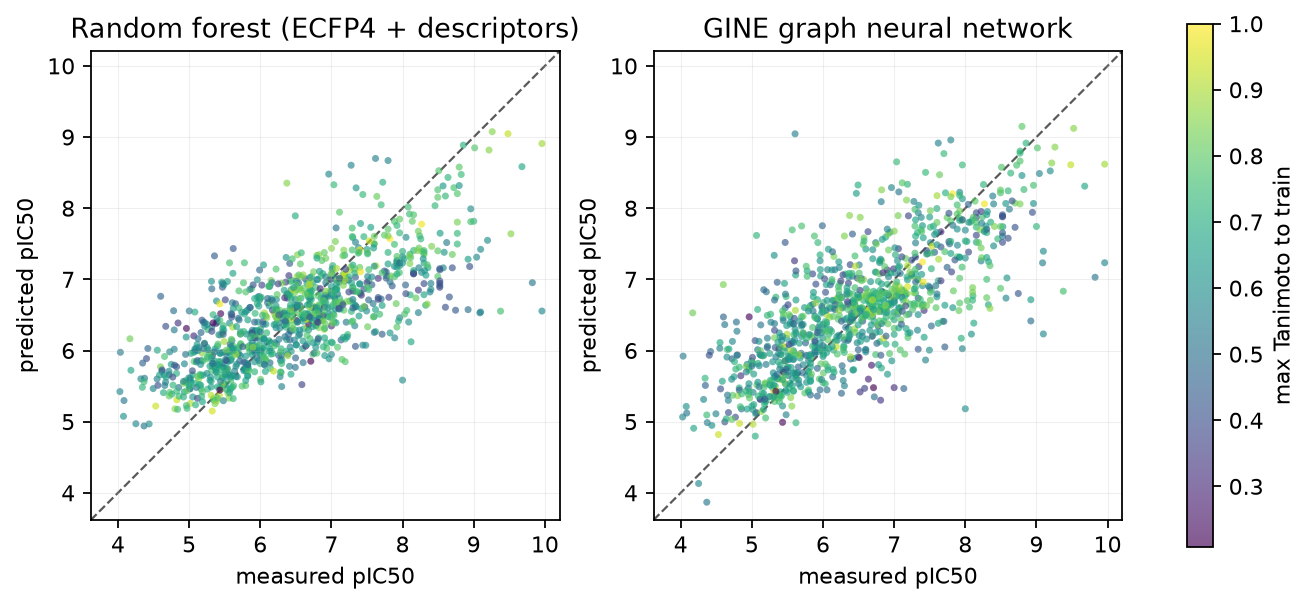

In [7]:
display(Image(filename=str(RESULTS / "fig_parity.png")))

## 5. Why — the diagnostics

The two analyses that turn "one model scored better" into an explanation.

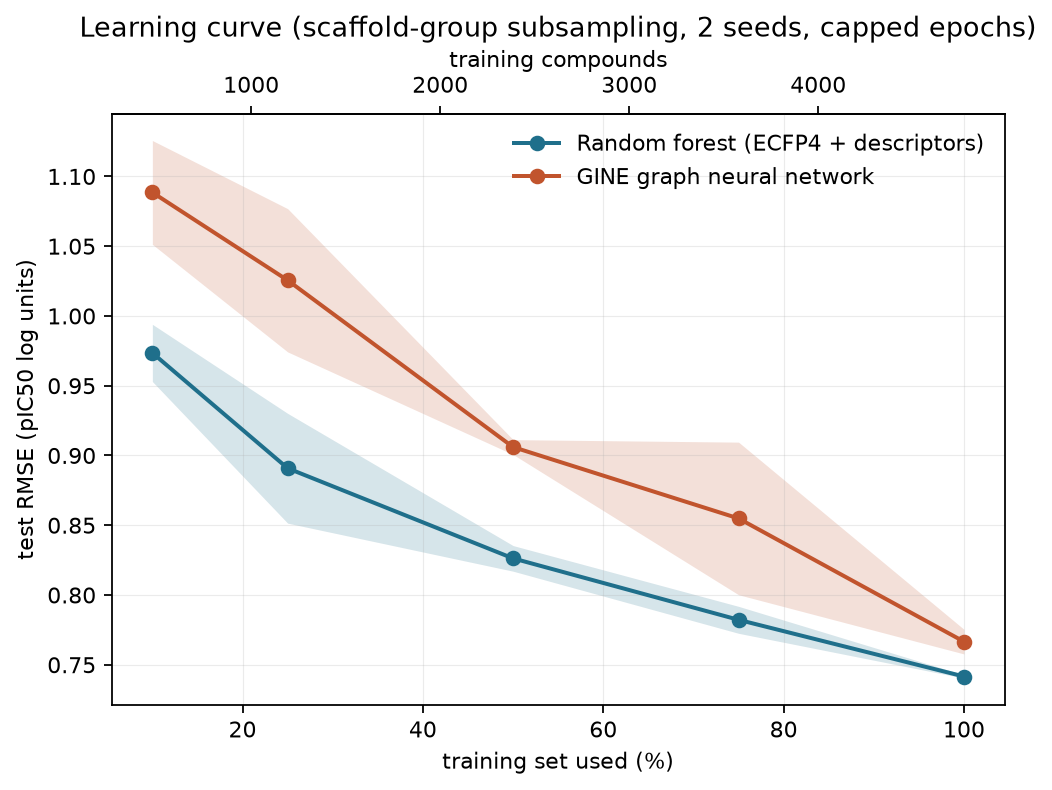

Random-split control - how much optimism a random split would have bought:


,model,random_rmse,scaffold_rmse,optimism
0,Random forest (ECFP4 + descriptors),0.6081,0.7367,0.1285
1,GINE graph neural network,0.6796,0.7357,0.0560


In [8]:
if diagnostics:
    display(Image(filename=str(RESULTS / "fig_learning_curve.png")))
    ctrl = diagnostics["random_split_control"]
    rows = []
    for label in (comparison["labels"]["a"], comparison["labels"]["b"]):
        rows.append({"model": label, **{k: round(v, 4) for k, v in ctrl[label].items()}})
    print("Random-split control - how much optimism a random split would have bought:")
    display(pd.DataFrame(rows))
else:
    print("diagnostics.json not present; run scripts/07_diagnostics.py")

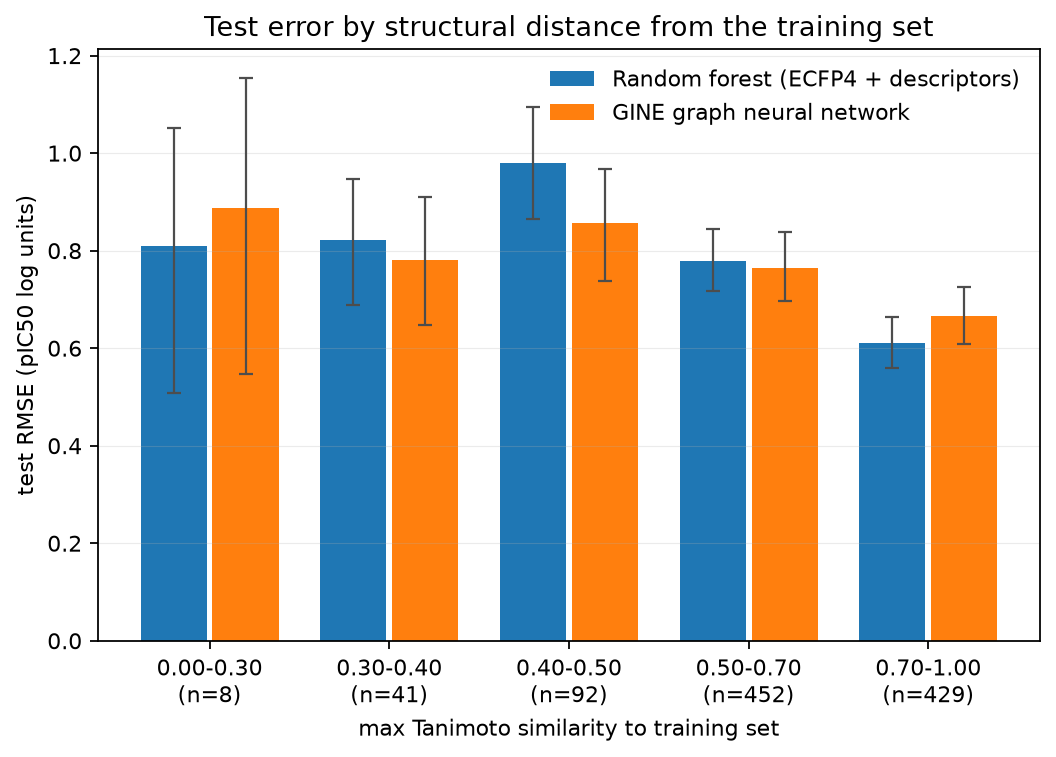

,similarity bin,n,Random forest (ECFP4 + descriptors),GINE graph neural network
0,0.00-0.30,8,0.8103,0.8882
1,0.30-0.40,41,0.8215,0.7813
2,0.40-0.50,92,0.9795,0.8559
3,0.50-0.70,452,0.7780,0.7640
4,0.70-1.00,429,0.6104,0.6666


In [9]:
display(Image(filename=str(RESULTS / "fig_stratified_by_similarity.png")))

strat = comparison["stratified_by_similarity"]
display(pd.DataFrame({
    "similarity bin": strat["bins"], "n": strat["counts"],
    comparison["labels"]["a"]: np.round(strat[comparison["labels"]["a"]], 4),
    comparison["labels"]["b"]: np.round(strat[comparison["labels"]["b"]], 4),
}))

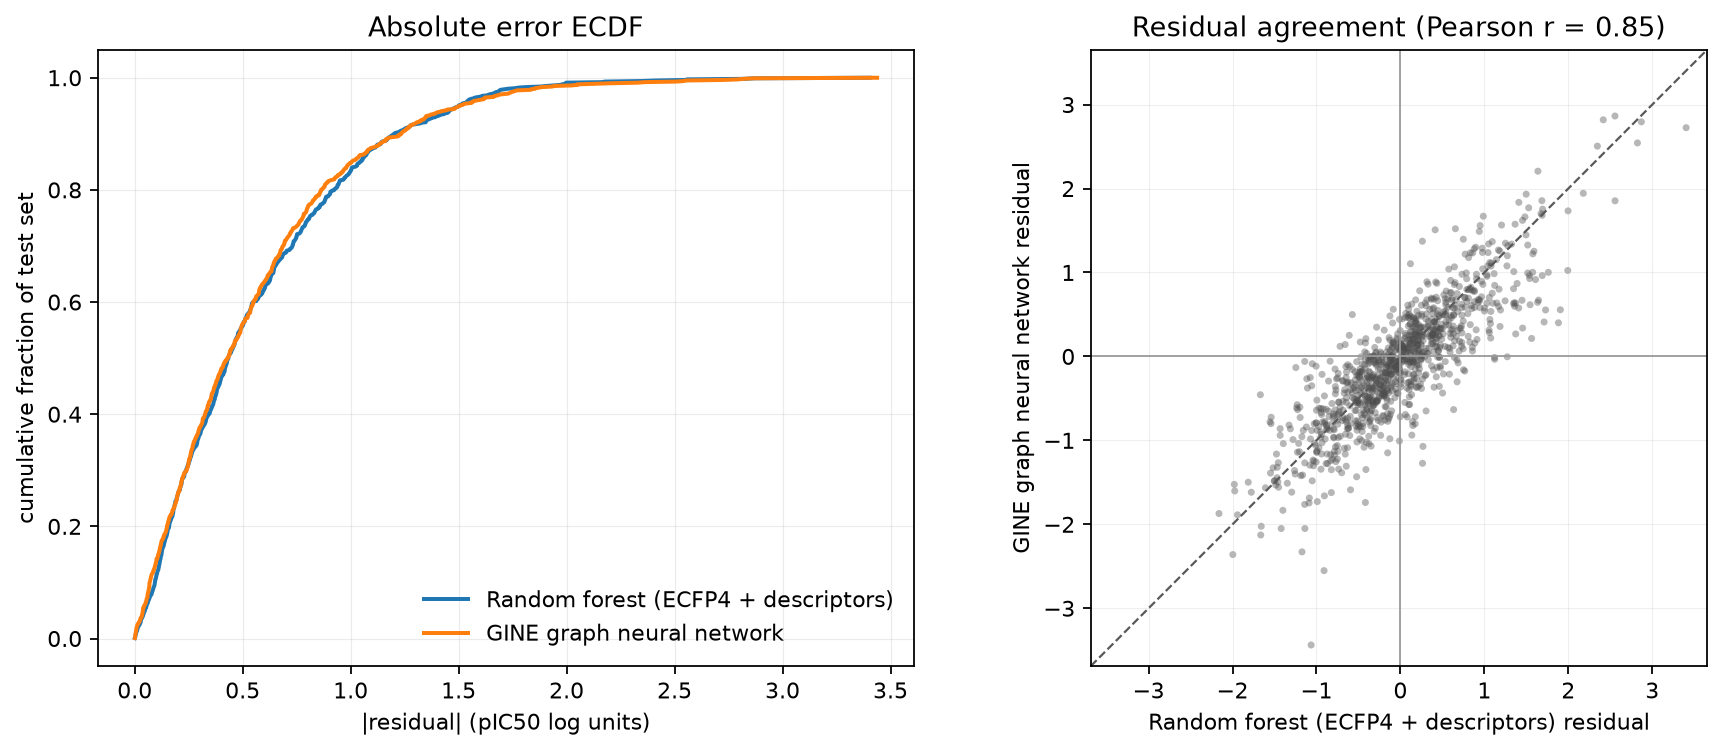

residual correlation between the two models: 0.852

By number of independent measurements (a proxy for label quality):


,n,Random forest (ECFP4 + descriptors),GINE graph neural network
single measurement,933.0,0.729119,0.732317
replicated (>=2),89.0,0.811591,0.770130


In [10]:
display(Image(filename=str(RESULTS / "fig_error_distributions.png")))
print("residual correlation between the two models:",
      round(comparison["residual_correlation"], 3))
print("\nBy number of independent measurements (a proxy for label quality):")
display(pd.DataFrame(comparison["stratified_by_replicates"]).T)

## 6. What the forest looked at

If the twelve bulk descriptors carried most of the signal, the headline comparison would really
be about molecular size and polarity rather than substructure. The ablations settle that.

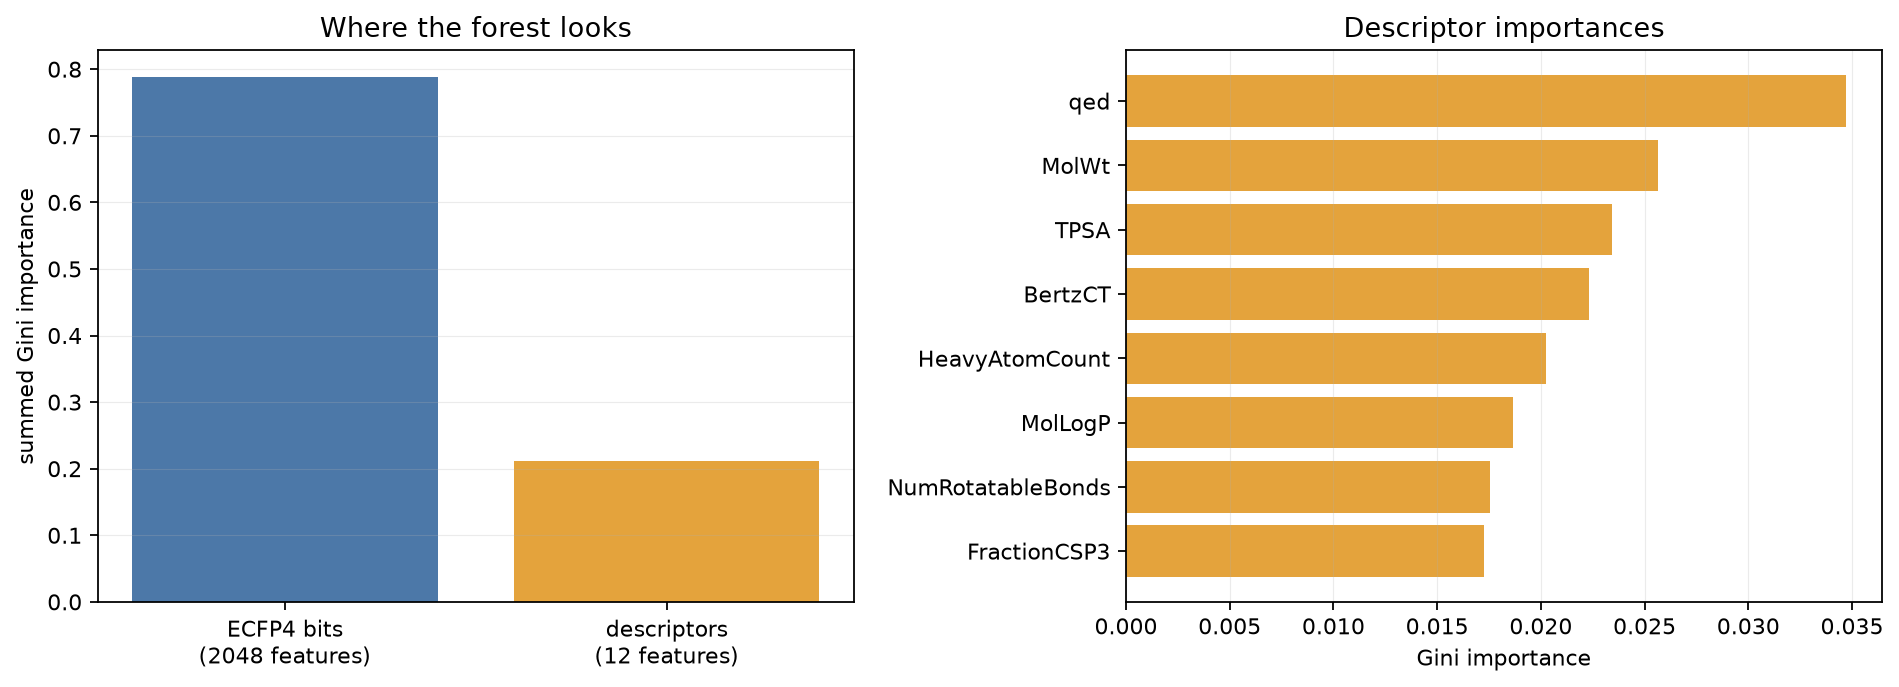

,n_features,rmse,spearman,r2
ecfp4_only,2048.0,0.7477,0.7404,0.5354
descriptors_only,12.0,0.9002,0.5682,0.3265
fcfp4_plus_desc,2060.0,0.7601,0.7420,0.5199
ecfp6_plus_desc,2060.0,0.7412,0.7534,0.5434


In [11]:
display(Image(filename=str(RESULTS / "fig_rf_importance.png")))
display(pd.DataFrame(rf_metrics["ablations"]).T[["n_features", "rmse", "spearman", "r2"]].round(4))

## 7. Limitations

See the README for the full list. The ones that bound every number above:

- **Label noise sets the floor.** The 6,816 compounds come from 1,116 assays across 781
  publications, so the labels carry inter-laboratory variation that no model can predict.
  Published reproducibility for ChEMBL IC50 data is roughly 0.5–0.7 log units.
- **Stereochemistry is stripped**, because ChEMBL annotates it inconsistently across papers and
  keeping it would create phantom duplicate compounds that leak across folds.
- **Censored measurements are excluded**, which truncates the low-potency tail and makes every
  classification metric look slightly better than it should.
- **One target, one assay type, in silico only.** Nothing here was tested experimentally.